In [1]:
import pandas as pd

df = pd.read_csv("../data/llm_requests.csv")

In [3]:
SLA_THRESHOLD_MS = 3000

df["slow_request"] = (
    df["latency_ms"] > SLA_THRESHOLD_MS
).astype(int)

In [8]:
df[
    ["latency_ms", "slow_request"]
].head(10)

,latency_ms,slow_request
0,2836,0
1,1952,0
2,1773,0
3,2006,0
4,3536,1
5,2589,0
6,1822,0
7,1345,0
8,2091,0
9,2855,0


In [10]:
df["slow_request"].value_counts()

slow_request
0    355
1    145
Name: count, dtype: int64

In [12]:
df["slow_request"].value_counts(normalize=True)

slow_request
0    0.71
1    0.29
Name: proportion, dtype: float64

In [14]:
features = [
    "model",
    "input_tokens",
    "output_tokens",
    "concurrent_requests",
    "region",
]

X = df[features]
y = df["slow_request"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training distributions:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Training distributions:
slow_request
0    0.71
1    0.29
Name: proportion, dtype: float64

Test distribution:
slow_request
0    0.71
1    0.29
Name: proportion, dtype: float64


In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = [
    "input_tokens",
    "output_tokens",
    "concurrent_requests",
]

categorical_features = [
    "model",
    "region",
]

preprocessor = ColumnTransformer(
    transformers = [
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

classification_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [38]:
classification_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['model','input_tokens','output_tokens','concurrent_requests','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [40]:
y_pred = classification_pipeline.predict(X_test)
y_proba = classification_pipeline.predict_proba(X_test)

In [42]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

In [44]:
y_proba[:5]

array([[0.88478741, 0.11521259],
       [0.92778036, 0.07221964],
       [0.91235237, 0.08764763],
       [0.95843829, 0.04156171],
       [0.3104759 , 0.6895241 ]])

In [48]:
classification_pipeline.named_steps["model"].classes_

array([0, 1])

In [53]:
y_proba = classification_pipeline.predict_proba(X_test)[:,1]

In [55]:
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "probability_slow": y_proba
})

results.head(10)

,actual,predicted,probability_slow
0,0,0,0.115213
1,0,0,0.072220
2,0,0,0.087648
3,0,0,0.041562
4,1,1,0.689524
5,0,0,0.135609
6,1,1,0.582900
7,0,0,0.014744
8,0,0,0.135752
9,0,0,0.101216


In [59]:
classification_pipeline.fit(X_train, y_train)

y_pred = classification_pipeline.predict(X_test)
y_proba = classification_pipeline.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "probability_slow": y_proba
})

results.head(10)

,actual,predicted,probability_slow
0,0,0,0.115213
1,0,0,0.072220
2,0,0,0.087648
3,0,0,0.041562
4,1,1,0.689524
5,0,0,0.135609
6,1,1,0.582900
7,0,0,0.014744
8,0,0,0.135752
9,0,0,0.101216


In [70]:
logistic_model = classification_pipeline.named_steps["model"]
fitted_preprocessor = classification_pipeline.named_steps["preprocessor"]

In [74]:
print("Intercept:", logistic_model.intercept_)
print("Coefficients:", logistic_model.coef_)

Intercept: [0.90462867]
Coefficients: [[ 1.34403961  1.6195198   1.67768243 -2.87445777 -5.03621689 -1.00618351
  -0.58204065]]


In [80]:
feature_names = fitted_preprocessor.get_feature_names_out()

for feature, coefficient in zip(
    feature_names,
    logistic_model.coef_[0]
):
    print(f"{feature}: {coefficient:.4f}")

num__input_tokens: 1.3440
num__output_tokens: 1.6195
num__concurrent_requests: 1.6777
cat__model_medium: -2.8745
cat__model_small: -5.0362
cat__region_us-east: -1.0062
cat__region_us-west: -0.5820


In [82]:
request = X_test.iloc[[4]]
request

,model,input_tokens,output_tokens,concurrent_requests,region
390,medium,3077,940,6,us-east


In [90]:
request_preprocessed = fitted_preprocessor.transform(request)

In [96]:
request_values = request_preprocessed[0]

for feature, value in zip(
    feature_names,
    request_values
):
    print(f"{feature}: {value:.4f}")

num__input_tokens: 0.8929
num__output_tokens: 1.5449
num__concurrent_requests: 0.0429
cat__model_medium: 1.0000
cat__model_small: 0.0000
cat__region_us-east: 1.0000
cat__region_us-west: 0.0000


In [98]:
import numpy as np

z = (
    logistic_model.intercept_[0]
    + np.dot(logistic_model.coef_[0], request_values)
)

print("z:", z)

z: 0.7978953519099222


In [100]:
print(f"Intercept: {logistic_model.intercept_[0]:.4f}")

for feature, value, coef in zip(
    feature_names,
    request_values,
    logistic_model.coef_[0]
):
    contribution = value * coef

    print(
        f"{feature}: "
        f"{value:.4f} x {coef:.4f} "
        f"= {contribution:.4f}"
    )

Intercept: 0.9046
num__input_tokens: 0.8929 x 1.3440 = 1.2001
num__output_tokens: 1.5449 x 1.6195 = 2.5019
num__concurrent_requests: 0.0429 x 1.6777 = 0.0719
cat__model_medium: 1.0000 x -2.8745 = -2.8745
cat__model_small: 0.0000 x -5.0362 = -0.0000
cat__region_us-east: 1.0000 x -1.0062 = -1.0062
cat__region_us-west: 0.0000 x -0.5820 = -0.0000


In [104]:
probability = 1 / (1 + np.exp(-z))

print("Probability slow:", probability)

Probability slow: 0.6895240965826364


In [106]:
classification_pipeline.predict_proba(request)[:,1]

array([0.6895241])

In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[69,  2],
       [ 1, 28]])

In [110]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

True Negatives: 69
False Positives: 2
False Negatives: 1
True Positives: 28


In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

Accuracy: 0.9700
Precision 0.9333
Recall: 0.9655
F1: 0.9492


### Classification metrics interpretation

#### Accuracy

Accuracy measures the proportion of all predictions that were correct.

It answers:

> Out of all requests, how many were classified correctly?

For this model:

- Accuracy = 97%

This means that 97 out of 100 test requests were classified correctly.

However, accuracy alone can be misleading when the dataset is imbalanced, because a model could obtain a relatively high accuracy by mostly predicting the majority class.


#### Precision

Precision measures how reliable the positive predictions are.

It answers:

> Out of all requests predicted as `slow`, how many were actually slow?

For this model:

- Precision = 93.33%

This means that when the model predicts an SLA violation, it is correct approximately 93% of the time.

Low precision would mean many false alarms (`False Positives`).


#### Recall

Recall measures how many real positive cases the model successfully detects.

It answers:

> Out of all requests that actually violated the SLA, how many did the model detect?

For this model:

- Recall = 96.55%

This means that the model detected approximately 96.6% of the real SLA violations.

Low recall means that many slow requests are missed (`False Negatives`).


#### F1 Score

F1 Score combines Precision and Recall into a single metric.

It is useful when both false positives and false negatives matter and we want a balance between:

- detecting real SLA violations
- avoiding unnecessary alerts

For this model:

- F1 = 94.92%


### Most important metric for this SLA use case

For this particular use case, **Recall is especially important**.

A False Negative means:

> The request actually violated the SLA, but the model predicted that it was normal.

If the goal of the system is to detect potential SLA violations before they become a problem, missing a slow request can be more costly than generating an occasional false alarm.

Therefore:

- High Recall → fewer SLA violations are missed
- High Precision → fewer unnecessary SLA alerts
- F1 → useful when we want to balance both

For this use case, we may prefer slightly lower Precision if it allows us to achieve higher Recall.

In [119]:
threshold = 0.3

y_pred_threshold = (y_proba >= threshold).astype(int)

In [121]:
y_pred_threshold

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0])

In [125]:
from sklearn.metrics import precision_score, recall_score, f1_score

precesion = precision_score(y_test, y_pred_threshold)
recall = recall_score(y_test, y_pred_threshold)
f1 = f1_score(y_test, y_pred_threshold)

print(f"Threshold: {threshold}")
print(f"Precision: {precesion:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")


Threshold: 0.3
Precision: 0.8529
Recall: 1.0000
F1: 0.9206


In [127]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")


Threshold: 0.3
Precision: 0.8529
Recall: 1.0000
F1: 0.9206

Threshold: 0.5
Precision: 0.9333
Recall: 0.9655
F1: 0.9492

Threshold: 0.7
Precision: 1.0000
Recall: 0.6897
F1: 0.8163


In [131]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = classification_pipeline.predict_proba(X_test)[:,1]

In [144]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9990


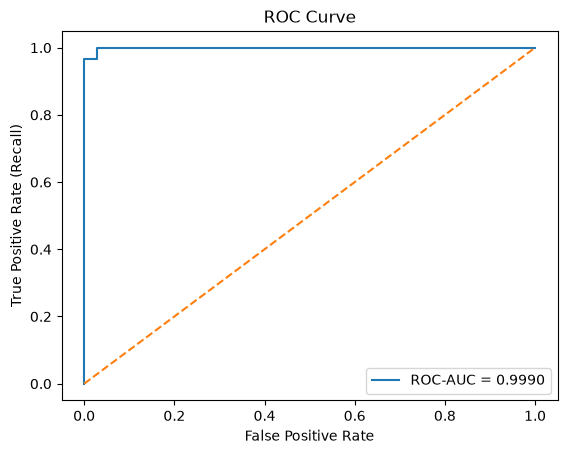

In [146]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [150]:
for threshold, false_positive_rate, true_positive_rate in zip(
    thresholds[:10],
    fpr[:10],
    tpr[:10]
):
    print(
        f"Threshold={threshold:.4f} "
        f"FPR={false_positive_rate:.4f} "
        f"TPR={true_positive_rate:.4f}"
    )

Threshold=inf FPR=0.0000 TPR=0.0000
Threshold=0.9963 FPR=0.0000 TPR=0.0345
Threshold=0.5141 FPR=0.0000 TPR=0.9655
Threshold=0.5045 FPR=0.0282 TPR=0.9655
Threshold=0.4555 FPR=0.0282 TPR=1.0000
Threshold=0.0001 FPR=1.0000 TPR=1.0000


### ROC and ROC-AUC interpretation

The ROC curve evaluates the classifier across different probability
thresholds.

- TPR (True Positive Rate) is equivalent to Recall and measures how many
  real SLA violations are detected.
- FPR (False Positive Rate) measures how many normal requests are incorrectly
  classified as SLA violations.

For this use case, the desired region of the ROC curve is close to the
top-left corner:

- high TPR / Recall
- low FPR

The model achieved a ROC-AUC of `0.9990`, indicating an excellent ability
to separate slow and normal requests across different thresholds.

A threshold around `0.4555` is particularly interesting in this test set:

- TPR / Recall = 100%
- FPR ≈ 2.82%
- False Negatives = 0
- False Positives = 2

Since missing an actual SLA violation is considered more costly than
generating a small number of false alarms, this illustrates why threshold
selection should be driven by the business cost of False Negatives and
False Positives.

ROC-AUC evaluates the ranking/discrimination ability of the classifier;
it is not the same as Accuracy.

### ROC-AUC interpretation

ROC-AUC measures the classifier's ability to distinguish between the positive
and negative classes across different classification thresholds.

The model achieved:

ROC-AUC = 0.9990

This indicates an almost perfect ability to rank slow requests above normal
requests.

ROC-AUC is not the same as Accuracy.

- Accuracy evaluates predictions at a specific threshold.
- ROC-AUC evaluates the model's discrimination ability across many thresholds.

An AUC close to 1.0 indicates excellent class separation, while an AUC close
to 0.5 indicates performance similar to random guessing.

In [154]:
from sklearn.model_selection import cross_validate

In [156]:
cv_results = cross_validate(
    classification_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

In [161]:
print("Recall:", cv_results["test_recall"])
print("ROC-AUC:", cv_results["test_roc_auc"])

Recall: [0.79166667 1.         0.82608696 0.7826087  0.7826087 ]
ROC-AUC: [0.99107143 0.99542334 0.97025172 0.98855835 0.99237223]


In [167]:
print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall: {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1: {cv_results['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC: {cv_results['test_roc_auc'].mean():.4f}")

Mean Accuracy: 0.9225
Mean Precision: 0.9028
Mean Recall: 0.8366
Mean F1: 0.8617
Mean ROC-AUC: 0.9875


In [169]:
print(
    f"Recall std: "
    f"{cv_results['test_recall'].std():.4f}"
)

Recall std: 0.0833


### Classification cross-validation

5-fold cross-validation produced:

- Mean Accuracy: `0.9225`
- Mean Precision: `0.9028`
- Mean Recall: `0.8366`
- Mean F1: `0.8617`
- Mean ROC-AUC: `0.9875`
- Recall standard deviation: `0.0833`

The classifier shows excellent discrimination across the folds, as indicated
by the consistently high ROC-AUC.

However, Recall at the default `0.5` threshold is lower and more variable.

This suggests that the model is generally good at ranking slow requests above
normal requests, but the default classification threshold may not be optimal
for an SLA use case where False Negatives are particularly costly.

Threshold selection should therefore be treated as a business decision and
tuned using training/validation data rather than the final test set.

In [172]:
from sklearn.model_selection import GridSearchCV

In [174]:
param_grid = {
    "model__C" : [0.01, 0.1, 1, 10, 100]
}

In [176]:
grid_search = GridSearchCV(
    estimator = classification_pipeline,
    param_grid = param_grid,
    scoring = "recall",
    cv = 5
)

In [178]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [184]:
print("Best C:", grid_search.best_params_)
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

Best C: {'model__C': 100}
Best CV Recall: 0.8967


In [186]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score"
    ]
]

,param_model__C,mean_test_score,std_test_score
0,0.01,0.086594,0.047963
1,0.10,0.698913,0.132751
2,1.00,0.836594,0.083258
3,10.00,0.879348,0.050564
4,100.00,0.896739,0.051673


In [194]:
best_model = grid_search.best_estimator_

In [200]:
grid_search.best_params_
grid_search.best_score_

np.float64(0.8967391304347826)

In [202]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

In [204]:
best_model = grid_search.best_estimator_

In [206]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [212]:
oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:,1]

In [226]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_train,
    oof_proba
)

In [228]:
target_recall = 0.95

candidates = []

for threshold, precision, recall in zip(
    thresholds,
    precision_values[:-1],
    recall_values[:-1]
):
    if recall >= target_recall:
        candidates.append(
            (threshold, precision, recall)
        )

In [230]:
best_threshold = max(
    candidates,
    key=lambda x: x[1]
)

print(
    f"Threshold: {best_threshold[0]:.4f}"
)
print(
    f"Precision: {best_threshold[1]:.4f}"
)
print(
    f"Recall: {best_threshold[2]:.4f}"
)

Threshold: 0.2358
Precision: 0.8473
Recall: 0.9569


In [234]:
best_model = grid_search.best_estimator_
test_proba = best_model.predict_proba(X_test)[:,1]

In [236]:
selected_threshold = best_threshold[0]

test_pred = (
    test_proba >= selected_threshold
).astype(int)

In [238]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cm = confusion_matrix(y_test, test_pred)

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

True Negatives: 69
False Positives: 2
False Negatives: 0
True Positives: 29


In [240]:
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

# ROC-AUC uses probabilities, not the final 0/1 predictions
roc_auc = roc_auc_score(y_test, test_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.9800
Precision: 0.9355
Recall: 1.0000
F1: 0.9667
ROC-AUC: 0.9990


## Final Classification Model

The final classification system uses:

- Logistic Regression with `C=100`
- A custom classification threshold of `0.2358`
- StandardScaler for numerical features
- OneHotEncoder for categorical features

The hyperparameter was selected using 5-fold cross-validation with Recall
as the optimization metric.

The classification threshold was selected from out-of-fold training
probabilities, targeting a Recall of at least 95% while maximizing Precision.

### Final test results

- Accuracy: `0.9800`
- Precision: `0.9355`
- Recall: `1.0000`
- F1 Score: `0.9667`
- ROC-AUC: `0.9990`

Confusion Matrix:

- True Negatives: `69`
- False Positives: `2`
- False Negatives: `0`
- True Positives: `29`

The final model detected all SLA violations in the test set, resulting in
zero False Negatives.

This behavior matches the business objective: missing a real SLA violation
is considered more costly than producing a small number of false alarms.

The results also demonstrate that model configuration and decision threshold
are separate concerns:

- `C` controls the regularization of Logistic Regression.
- The classification threshold controls the trade-off between False
  Negatives and False Positives.
- ROC-AUC measures discrimination ability independently of the selected
  classification threshold.